# The general gist of the code
First we have to open the videos and then start analysing them. To analyse the different wells we need to know where the wells are and thus we need to define different regions of interest (ROI's) for the code to look at. We do this by first determining where the wells are and then cropping the frames so only one well at a time is visible for the code. Now that we have the ROI's we can calculate the brightness of the wells and comparing them to the previous frame. Once there is a difference greater than the threshold set a freezing event is detected and the code stops looking at that particular well to prevent false positives.

# Import libraries
* the opencv library was used for opening the video and processing it
* numpy was used for various calculations
* matplot was used for plotting the various results

In [1]:
#importing libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import subprocess
import os

# Step 1: loading the video in python

Extra step: convert video from HEVC to AVC with subprocess and ffmpeg. 

ffmpge needs to be installed (https://ffmpeg.org/download.html#build-windows), the essentials build is sufficient. version 7.1 from gyan.dev was used for this project. Make sure to add it to path on your device.

In [2]:
def convert_video(tag):
    """
    Convert a video to H.264 format using a tag to identify the file.

    Parameters:
    - tag (str): Tag to identify the input and output video file name (e.g., '20250107_untreated').

    Returns:
    - output_video (str): Path to the converted video file.
    """
    # Define the folder path where videos are stored
    folder = "C:/BEP/Videos"

    # Construct the input and output file paths
    input_video = os.path.join(folder, f"{tag}.MP4")
    output_video = os.path.join(folder, f"output_{tag}.mp4")

    # FFmpeg command to convert the video
    command = [
        'ffmpeg',
        '-i', input_video,
        '-vcodec', 'libx264',
        '-acodec', 'aac',
        output_video
    ]

    # Run the FFmpeg command
    process = subprocess.run(command, capture_output=True, text=True)

    if process.returncode == 0:
        print(f"Video conversion successful! Output file: {output_video}")
    else:
        print("Error occurred during conversion:")
        print(process.stderr)

    return output_video

In [3]:
start_time = time.time()

#Videotags

# tag = "12062026_purewater"
# left = 'pure'
# right = 'pure'
# tag = "15062026O_purewater"
# left = "left"
# right = "right"
# tag = "16062026O_purewater"
# left = "left"
# right = "right"
# tag = "17062026_purewater"
# left = "left"
# right = "right"
# tag = "18062026_purewater"
# left = "left"
# right = "right"

#Convert the video
output_path = convert_video(tag) #uncomment to convert video
output_path = f"C:/BEP/Videos/output_{tag}.mp4"

print("Execution time:", time.time() - start_time)

Video conversion successful! Output file: C:/BEP/Videos\output_GX011427.mp4
Execution time: 0.7402374744415283


In [4]:
# Open the video

cap = cv2.VideoCapture(output_path)

frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print("number of frames in ",tag, "is:", frames)


#check if the video is opened correctly
if not cap.isOpened():
    print("Error: can't open the video")
    exit()

number of frames in  GX011427 is: 405


# Step 2: defining the region of interest for the well

In [5]:
# FOR A VIDEO IN 1080p
# defining a few variables already
image = None
image_prev = None

radius = 9

#the values inserted were used for my data, these likely will differ depending on the experiment
#With the gopro in the holder and same settings, values should differ only slightly
#right and left meaning the right or left box
position_left_x = 744
position_left_y = 378

position_right_x = 1014
position_right_y = 378
#unfortunately hard coded :(

#void means the distance between the wells which I have called the "void"
void_right = 27
void_left = 27 #same as void right

To find the different wells positions we can have a double for loop to loop over the grid (as the wells are placed in a grid). By drawing some circles on the frames we can see where the wells are and if the regions of interest are properly defined. By first drawing a circle and then shifting the position of the circle to draw them again we can draw circles on the wells and see if regions of interest are properly defined. We will use this information later to crop the images and thus crop out the wells out of the frame.

In [6]:
#made by Huub Reitsma
#initilize frame count
frame_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    frame_count += 1
    if frame_count == 1:
        #Saving the current frame
        image = frame
        
    #looping over grid
    for i in range(0,12):
        for j in range(0,8):
            x_shift = j*void_right
            y_shift = i*void_right

            # finding the positions of the wells (adjust the variables above if the circles do not match up with the wells). This is a trial and error process.
            image_test_left = cv2.circle(image, (position_left_x+x_shift,position_left_y+y_shift), radius, (0,255,0))
            image_test_right = cv2.circle(image, (position_right_x+x_shift,position_right_y+y_shift), radius, (0,255,0))
    break

#showing the image, this opens in a different window!          
cv2.namedWindow("image", cv2.WINDOW_NORMAL)  
cv2.imshow("image", image_test_left) 
cv2.imshow("image", image_test_right) 
cv2.waitKey() #remove 3000 when editing grid, add 3000 when continuing the code , press restart kernell when want to do these steps again
cv2.destroyAllWindows()

# Step 3: calculating the brightness

In [7]:
# Function to calculate the average pixel intensity of an image
def calculate_brightness(image):
    # Convert the image to grayscale
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Calculate the average pixel intensity
    brightness = gray_image.mean()
    return brightness

Now that we have a function to calculate the brightness, we can see how the brightness of the wells evolve and determine from that what the threshold should be.

405 405


C:\Users\lucas\AppData\Local\Temp\ipykernel_9044\1632877742.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


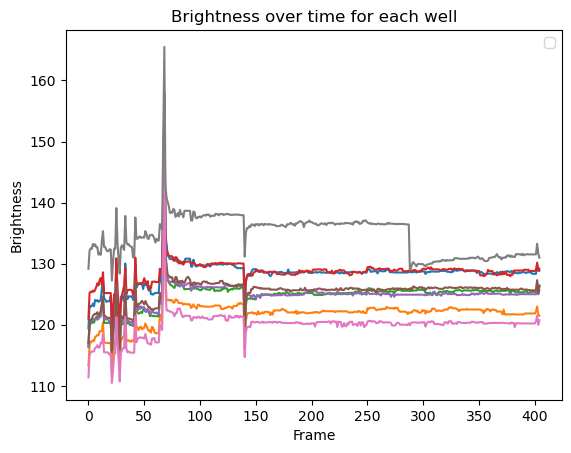

Execution time: 4.022940635681152


In [8]:
start_time = time.time()

# initialize the frame count to start at 0 again
frame_count = 0

# List to store brightness values for each well
brightness_values = [[[] for _ in range(8)] for _ in range(12)]

# Open the video
# cap = cv2.VideoCapture("/Users/wmvermeij/Documents/NatTU2024/BEP/12nov/12novgoedstable.mov")
# cap = cv2.VideoCapture("C:/Users/Bouchra/Desktop/BEP/Videos/Test/20250109_50microL_volledig_GoPro_houderopglas.mp4")
cap = cv2.VideoCapture(output_path)

#check if the video is opened correctly
if not cap.isOpened():
    print("Error: can't open the video")
    exit()
    
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    image = frame
    frame_count+=1
    
    #looping over the grid
    for i in range(0,12):
        for j in range(0,8):
            x_shift = j*void_right
            y_shift = i*void_right 
                 
            # crop images and calculate brightness
            image_cropped = image[(position_left_y-radius)+y_shift:(position_left_y+radius)+y_shift,(position_left_x-radius)+x_shift:(position_left_x+radius)+x_shift]
            brightness1 = calculate_brightness(image_cropped)
            
            # Store brightness values
            # if i==1 and j==6:
            # print(brightness1)
            brightness_values[i][j].append(brightness1)

print(len(brightness_values[3][5]),frame_count)

# Plotting brightness over time for each well
#plotting all the wells or a couple
#for i in range(0,12):
#    for j in range(0,8):
#        plt.plot(range(len(brightness_values[i][j])), brightness_values[i][j], label=f'Well ({i},{j})')

#plotting a couple of wells
plt.plot(range(len(brightness_values[9][1])),brightness_values[9][1])
plt.plot(range(len(brightness_values[0][1])),brightness_values[0][1])
plt.plot(range(len(brightness_values[4][2])),brightness_values[4][2])
plt.plot(range(len(brightness_values[10][7])),brightness_values[10][7])
plt.plot(range(len(brightness_values[9][0])),brightness_values[9][0])
plt.plot(range(len(brightness_values[5][1])),brightness_values[5][1])
plt.plot(range(len(brightness_values[0][0])),brightness_values[0][0])
plt.plot(range(len(brightness_values[11][3])),brightness_values[11][3])
plt.xlabel('Frame')
plt.ylabel('Brightness')
plt.legend()
plt.title('Brightness over time for each well')
plt.savefig("brightnessdrops_filtered")
plt.show()

print("Execution time:", time.time() - start_time)


Now we can add a threshold and the mechanism to count the amount of freezing events. In additions, an array is added that counts at what place a freezing event is detected and then notes this so this well is skipped the next time to prevent false positives.

In [17]:
def brightness_change(path, tag, block, side, brightness_threshold, row1, row2):
    """
    Processes a video to detect normalized brightness changes in wells over time.
    
    Parameters:
    - path: Path to the video file.
    - tag: Identifier for the experiment.
    - block: contents of the block (e.g. 50 microL)
    - side: left/right
    - brightness_threshold: Threshold for detecting a brightness change.
    - row1: starting row to consider (default=0)
    - row2: ending row to consider (default=12)
    
    Returns:
    - times: Array of frames where changes were detected.
    """
    # Initialize variables
    start_time = time.time()
    counter = 0
    frame_count = 0
    times = []
    wells = np.zeros((12,8))
    brightness_values = [[[] for _ in range(8)] for _ in range(12)]
    average = 30
    
    position = {
    "left": {"x": position_left_x, "y": position_left_y},
    "right": {"x": position_right_x, "y": position_right_y}
    }

    # Open the video
    cap = cv2.VideoCapture(path)
    if not cap.isOpened():
        print("Error: can't open the video")
        return None

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        

        frame_count += 1
        if frame_count == 1:
            image_prev = frame
            continue
      
        image = frame
        
        # Looping over the grid
        for i in range(row1,row2):
            for j in range(0,8):
                if wells[i,j] == 1:  # Skip already detected wells
                    continue
                
                y_shift = i * void_right
                x_shift = j * void_right
                
                # Crop images and calculate brightness
                image_cropped = image[
                (position[side]["y"] - radius) + y_shift : (position[side]["y"] + radius) + y_shift,
                (position[side]["x"] - radius) + x_shift : (position[side]["x"] + radius) + x_shift]
                brightness1 = calculate_brightness(image_cropped)
               
                image_prev_cropped = image_prev[
                (position[side]["y"] - radius) + y_shift : (position[side]["y"] + radius) + y_shift,
                (position[side]["x"] - radius) + x_shift : (position[side]["x"] + radius) + x_shift]
                brightness2 = calculate_brightness(image_prev_cropped)
                
                # Store brightness values
                brightness_values[i][j].append(brightness1)
                
                # Compare brightness of the images                 
                if len(brightness_values[i][j]) >= (average+2):
                    rolling_average = sum(brightness_values[i][j][-average:]) / average  # Last brightness values
                    if (brightness_values[i][j][-(average+1)] - rolling_average) > brightness_threshold:
                        counter += 1
                        wells[i, j] = 1
                        times.append(frame_count)

        image_prev = frame

    times = np.array(times) - average
    
    print(f"Results for {tag} {block}:")
    print(f"The total amount of wells detected is: {counter}")
    print("wells detected:")
    print(wells)
    print("frame count:", frame_count)
    print("times array:") 
    print(times)
    
    # Plotting brightness over time for each well
    for i in range(0,12):
        for j in range(0,8):
            plt.plot(range(len(brightness_values[i][j])), brightness_values[i][j], label=f'Well ({i},{j})')
    plt.xlabel('Frame')
    plt.ylabel('Brightness')
    plt.title('Brightness over Time for Each Well')
    plt.grid()
    plt.xticks(np.arange(0, frame_count+1, 100))
    plt.show()
    
    # Save detected times
    np.savetxt(f"times_{tag}_{block}.txt", times, fmt='%d')
    print("Execution time:", time.time() - start_time)
    
    return times

Results for GX011427 left:
The total amount of wells detected is: 96
wells detected:
[[1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]]
frame count: 405
times array:
[10 10 11 12 12 12 12 13 13 13 14 14 14 14 14 14 14 14 14 14 14 14 14 14
 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14
 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14
 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 26]


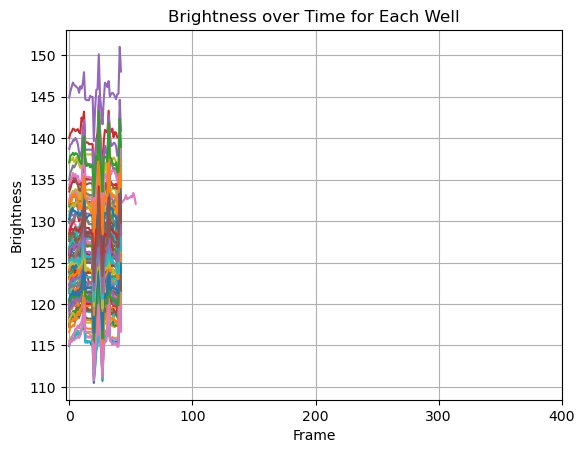

Execution time: 2.99650239944458


array([10, 10, 11, 12, 12, 12, 12, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 26])

In [18]:
brightness_threshold=2.3

brightness_change(output_path, tag, left, "left", brightness_threshold, 0,12)

Results for GX011427 right:
The total amount of wells detected is: 96
wells detected:
[[1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]]
frame count: 405
times array:
[11 11 12 12 12 13 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14
 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14
 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14
 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 26]


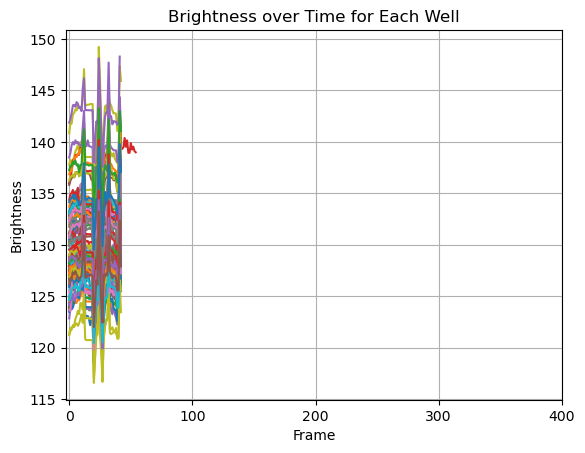

Execution time: 2.8056652545928955


array([11, 11, 12, 12, 12, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 26])

In [16]:
brightness_threshold=2.4

brightness_change(output_path, tag, right, "right", brightness_threshold, 0,12)

Now a feature is added which is not really needed but could be nice to have. The initial brightness of the wells is calculated and the brightness is then normalized with this value. The reason this could be useful is when somebody would walk by the experiment and cast a shadow at which the brightness of the overall video is lowered which would have triggered all the wells to be counted wrongly as freezing events. In the data used in this notebook no one walked by the experiment but this could be the case in later experiments.

In [17]:
def brightness_normalized(path, tag, block, side, brightness_threshold):
    """
    Processes a video to detect normalized brightness changes in wells over time.
    
    Parameters:
    - path: Path to the video file.
    - tag: Identifier for the experiment.
    - block: contents of the block (e.g. 50 microL)
    - side: left/right
    - brightness_threshold: Threshold for detecting a brightness change.
    - row1: starting row to consider (default=0)
    - row2: ending row to consider (default=12)
    
    Returns:
    - times: Array of frames where changes were detected.
    """
    # Initialize variables
    start_time = time.time()
    counter = 0
    frame_count = 0
    times = []
    initial_brightness = np.ones((12,8))
    wells = np.zeros((12,8))
    brightness_values = [[[] for _ in range(8)] for _ in range(12)]
    excluded_frames = []
    average = 30
    
    position = {
    "left": {"x": position_left_x, "y": position_left_y},
    "right": {"x": position_right_x, "y": position_right_y}
    }

    # Open the video
    cap = cv2.VideoCapture(path)
    if not cap.isOpened():
        print("Error: can't open the video")
        return None

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        
        frame_count += 1
        if frame_count == 1:
            image_prev = frame
            for i in range(0,12):
                for j in range(0,8):
                    y_shift = i * void_right
                    x_shift = j * void_right
                    image_cropped_initial = image_prev[
                    (position[side]["y"] - radius) + y_shift : (position[side]["y"] + radius) + y_shift,
                    (position[side]["x"] - radius) + x_shift : (position[side]["x"] + radius) + x_shift]
                    initial_brightness[i,j] = calculate_brightness(image_cropped_initial)
            continue

        # Saving the current frame
        image = frame     
        
        # Looping over the grid
        for i in range(0,12):
            for j in range(0,8):
                if wells[i,j] == 1:  # Skip already detected wells
                    continue
                
                y_shift = i * void_right
                x_shift = j * void_right
                
                # Crop images and calculate brightness
                image_cropped = image[
                (position[side]["y"] - radius) + y_shift : (position[side]["y"] + radius) + y_shift,
                (position[side]["x"] - radius) + x_shift : (position[side]["x"] + radius) + x_shift]
                brightness1 = calculate_brightness(image_cropped) / initial_brightness[i,j]
               
                image_prev_cropped = image_prev[
                (position[side]["y"] - radius) + y_shift : (position[side]["y"] + radius) + y_shift,
                (position[side]["x"] - radius) + x_shift : (position[side]["x"] + radius) + x_shift]
                brightness2 = calculate_brightness(image_prev_cropped) / initial_brightness[i,j]  
                
                # Store brightness values
                brightness_values[i][j].append(brightness1)

                # Compare brightness of the images                  
                if len(brightness_values[i][j]) >= (average+2):
                    rolling_average = sum(brightness_values[i][j][-average:]) / average  # Last 3 brightness values
                    if (brightness_values[i][j][-(average+1)] - rolling_average) > brightness_threshold:
                        counter += 1
                        wells[i, j] = 1
                        times.append(frame_count)
            

        image_prev = frame

    times = np.array(times) - average
    
    print(f"Results for {tag} {block}:")
    print(f"The total amount of wells detected is: {counter}")
    print("wells detected:")
    print(wells)
    print("frame count:", frame_count)
    print("times array:") 
    print(times)
    
    # Plotting brightness over time for each well
    for i in range(0,12):
        for j in range(0,8):
            plt.plot(range(len(brightness_values[i][j])), brightness_values[i][j], label=f'Well ({i},{j})')
    plt.xlabel('Frame')
    plt.ylabel('Brightness')
    plt.title('Brightness over Time for Each Well')
    plt.show()
    
    # Save detected times
    np.savetxt(f"times_{tag}_{block}.txt", times, fmt='%d')
    print("Execution time:", time.time() - start_time)
    
    return times

Results for GX011427 left:
The total amount of wells detected is: 96
wells detected:
[[1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]]
frame count: 405
times array:
[10 10 11 12 12 12 13 13 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14
 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14
 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14
 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 26 68]


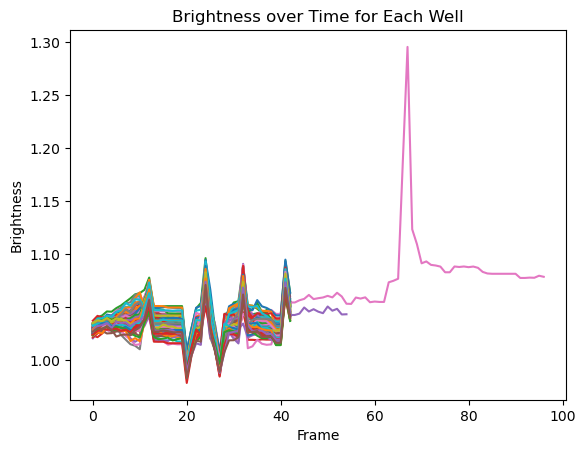

Execution time: 2.859396457672119


array([10, 10, 11, 12, 12, 12, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 26, 68])

In [20]:
brightness_threshold = 0.02
brightness_normalized(output_path, tag, left, "left", brightness_threshold)

Results for GX011427 right:
The total amount of wells detected is: 96
wells detected:
[[1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]]
frame count: 405
times array:
[11 11 12 12 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14
 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14
 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14
 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 26 26]


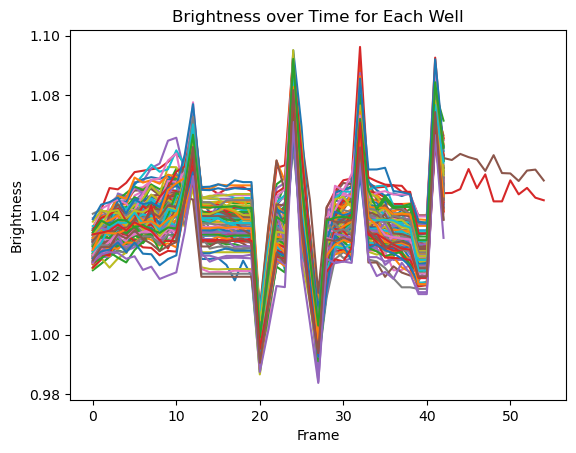

Execution time: 2.7900052070617676


array([11, 11, 12, 12, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 26, 26])

In [19]:
brightness_threshold = 0.02
brightness_normalized(output_path, tag, right, "right", brightness_threshold)